In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

warnings.filterwarnings('ignore')

In [182]:
df = pd.read_csv('student_mental_health_burnout.csv')

EDA


In [183]:
print(df.info())
print(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  int64  
 3   course                   150000 non-null  int64  
 4   year                     150000 non-null  int64  
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  float64
 14  phys

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,1,22,2,2,1,5.6,7.6,9.2,Medium,6,3,10,4,5.0,2.1,Good,71.240900,9.062928,Poor,Medium
1,2,19,2,1,2,4.6,4.9,2.8,Medium,6,10,7,4,5.0,0.3,Average,81.171568,5.523225,Average,Medium
2,3,28,1,2,2,8.3,3.8,7.9,Medium,9,4,10,5,5.0,0.3,Good,89.520514,8.869423,Poor,High
3,4,30,1,5,3,7.7,6.8,4.2,Medium,7,5,2,10,5.0,1.0,Average,93.378856,6.934854,Poor,Medium
4,5,26,2,5,3,4.8,7.2,8.1,Medium,5,2,8,8,5.0,2.2,Good,89.901019,7.416576,Average,Medium


In [184]:
df.tail()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
149995,149996,25,2,1,1,6.5,7.2,8.3,Medium,2,3,6,1,5.0,0.9,Good,65.284734,7.461461,Average,Medium
149996,149997,18,1,3,2,7.6,5.2,3.5,Medium,8,1,3,1,5.0,1.9,Good,64.861576,8.040681,Average,Medium
149997,149998,23,1,4,0,4.3,6.0,7.4,High,7,5,5,5,5.0,0.2,Poor,70.212552,7.657552,Good,Medium
149998,149999,28,0,4,3,6.3,8.3,5.7,Medium,6,5,10,2,5.0,3.3,Good,81.229325,6.622429,Poor,Medium
149999,150000,18,1,4,1,6.4,6.8,6.3,High,1,6,2,3,5.0,3.8,Poor,80.223182,7.510523,Poor,Medium


In [185]:
print(df.isnull().sum())

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64


Data Visualization


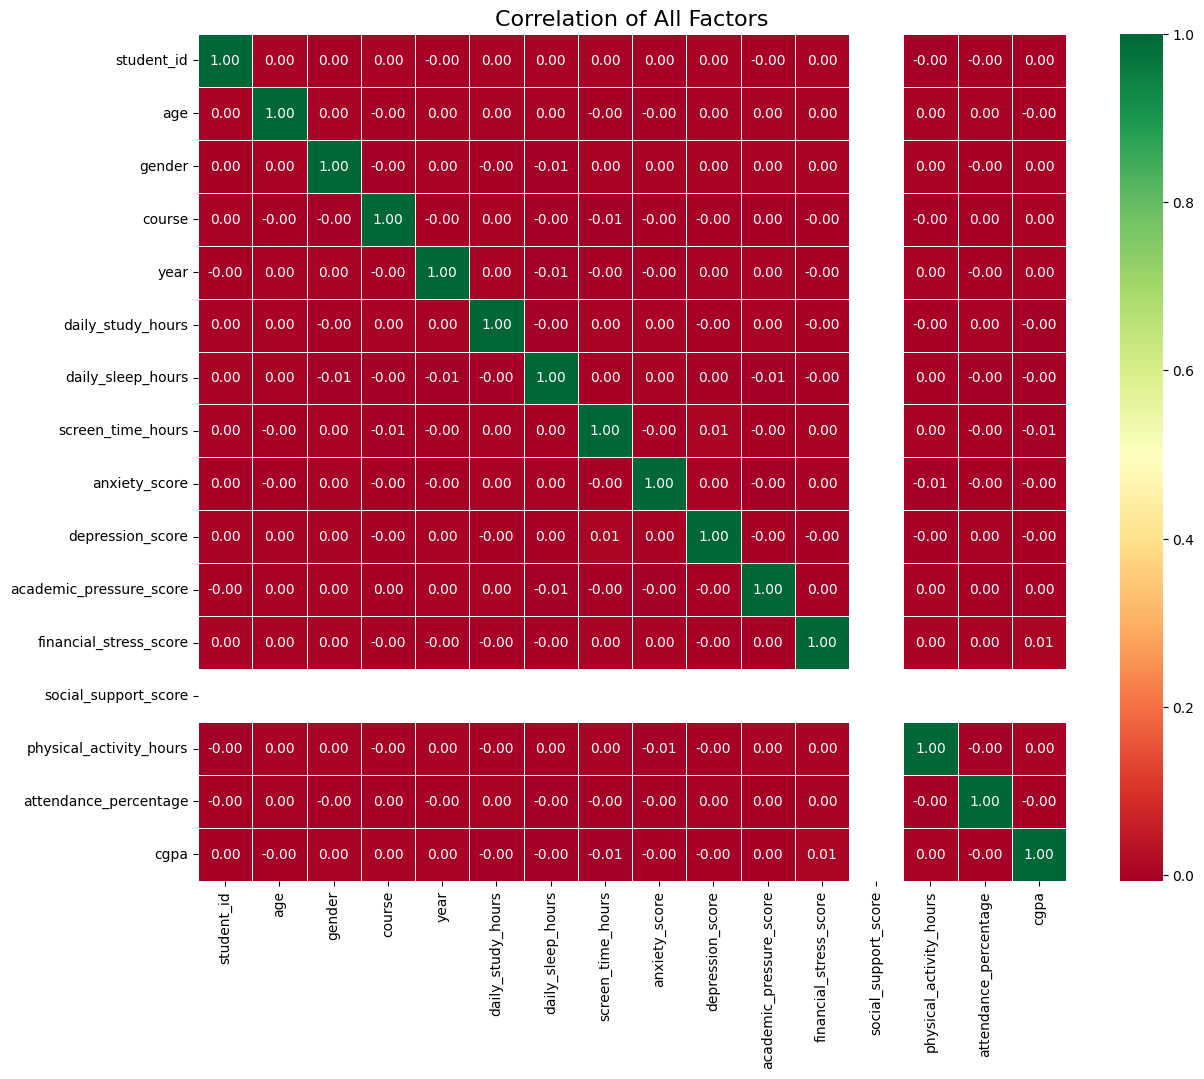

In [186]:
#Heatmap
plt.figure(figsize=(14, 11))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation of All Factors', fontsize=16)
plt.show()

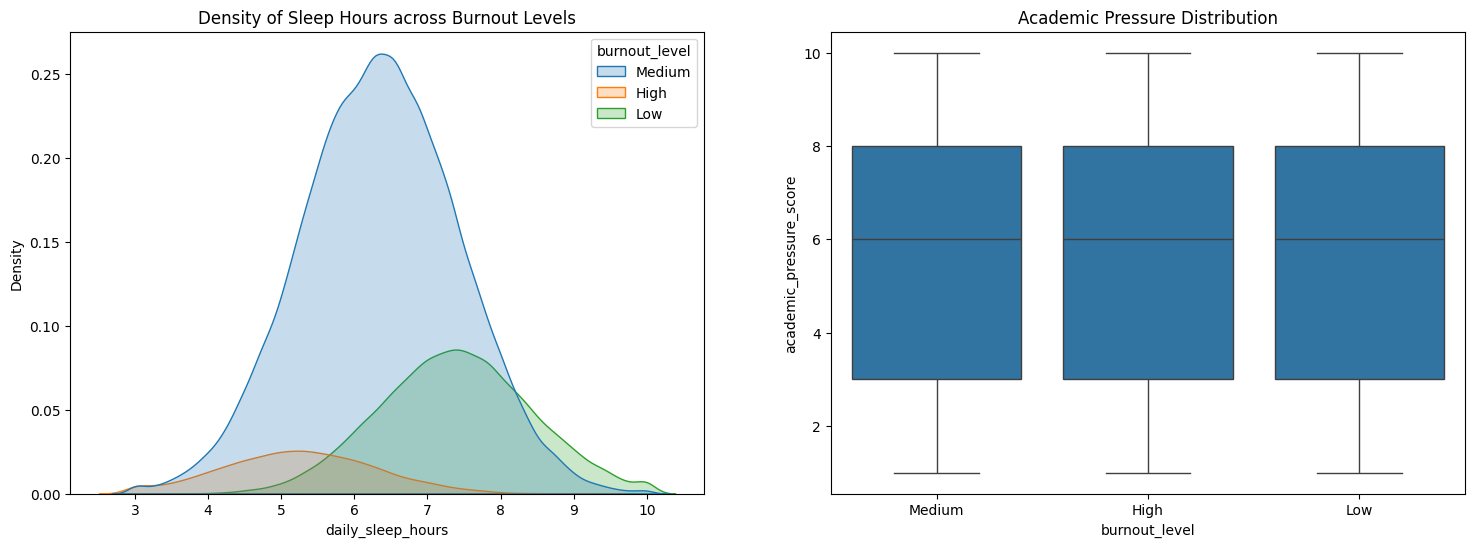

In [187]:


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(data=df, x='daily_sleep_hours', hue='burnout_level', fill=True, ax=axes[0])
axes[0].set_title('Density of Sleep Hours across Burnout Levels')

sns.boxplot(data=df, x='burnout_level', y='academic_pressure_score', ax=axes[1])
axes[1].set_title('Academic Pressure Distribution')
plt.show()



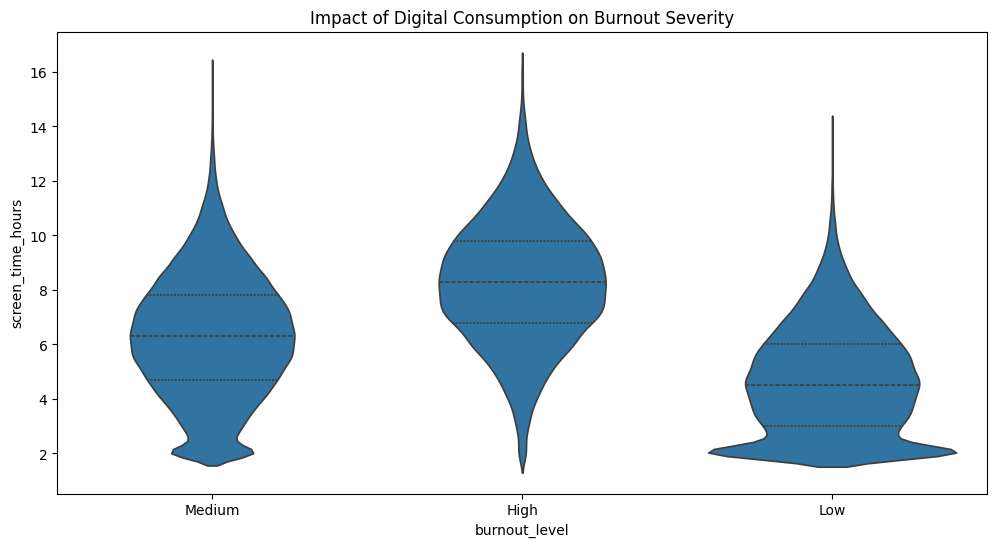

In [188]:

plt.figure(figsize=(12, 6))
sns.violinplot(x='burnout_level', y='screen_time_hours', data=df, inner="quart")
plt.title('Impact of Digital Consumption on Burnout Severity')
plt.show()

Data Preprocessing

In [189]:
df = df.dropna(subset=['burnout_level'])

In [190]:
df = df.fillna(df.median(numeric_only=True))
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,1,22,2,2,1,5.6,7.6,9.2,Medium,6,3,10,4,5.0,2.1,Good,71.240900,9.062928,Poor,Medium
1,2,19,2,1,2,4.6,4.9,2.8,Medium,6,10,7,4,5.0,0.3,Average,81.171568,5.523225,Average,Medium
2,3,28,1,2,2,8.3,3.8,7.9,Medium,9,4,10,5,5.0,0.3,Good,89.520514,8.869423,Poor,High
3,4,30,1,5,3,7.7,6.8,4.2,Medium,7,5,2,10,5.0,1.0,Average,93.378856,6.934854,Poor,Medium
4,5,26,2,5,3,4.8,7.2,8.1,Medium,5,2,8,8,5.0,2.2,Good,89.901019,7.416576,Average,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,25,2,1,1,6.5,7.2,8.3,Medium,2,3,6,1,5.0,0.9,Good,65.284734,7.461461,Average,Medium
149996,149997,18,1,3,2,7.6,5.2,3.5,Medium,8,1,3,1,5.0,1.9,Good,64.861576,8.040681,Average,Medium
149997,149998,23,1,4,0,4.3,6.0,7.4,High,7,5,5,5,5.0,0.2,Poor,70.212552,7.657552,Good,Medium
149998,149999,28,0,4,3,6.3,8.3,5.7,Medium,6,5,10,2,5.0,3.3,Good,81.229325,6.622429,Poor,Medium


In [191]:
qual_map = {'Poor': 0, 'Average': 1, 'Good': 2}

In [192]:
df['sleep_quality'] = df['sleep_quality'].map(qual_map)
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,1,22,2,2,1,5.6,7.6,9.2,Medium,6,3,10,4,5.0,2.1,2,71.240900,9.062928,Poor,Medium
1,2,19,2,1,2,4.6,4.9,2.8,Medium,6,10,7,4,5.0,0.3,1,81.171568,5.523225,Average,Medium
2,3,28,1,2,2,8.3,3.8,7.9,Medium,9,4,10,5,5.0,0.3,2,89.520514,8.869423,Poor,High
3,4,30,1,5,3,7.7,6.8,4.2,Medium,7,5,2,10,5.0,1.0,1,93.378856,6.934854,Poor,Medium
4,5,26,2,5,3,4.8,7.2,8.1,Medium,5,2,8,8,5.0,2.2,2,89.901019,7.416576,Average,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,25,2,1,1,6.5,7.2,8.3,Medium,2,3,6,1,5.0,0.9,2,65.284734,7.461461,Average,Medium
149996,149997,18,1,3,2,7.6,5.2,3.5,Medium,8,1,3,1,5.0,1.9,2,64.861576,8.040681,Average,Medium
149997,149998,23,1,4,0,4.3,6.0,7.4,High,7,5,5,5,5.0,0.2,0,70.212552,7.657552,Good,Medium
149998,149999,28,0,4,3,6.3,8.3,5.7,Medium,6,5,10,2,5.0,3.3,2,81.229325,6.622429,Poor,Medium


In [193]:
df['internet_quality'] = df['internet_quality'].map(qual_map)
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,1,22,2,2,1,5.6,7.6,9.2,Medium,6,3,10,4,5.0,2.1,2,71.240900,9.062928,0,Medium
1,2,19,2,1,2,4.6,4.9,2.8,Medium,6,10,7,4,5.0,0.3,1,81.171568,5.523225,1,Medium
2,3,28,1,2,2,8.3,3.8,7.9,Medium,9,4,10,5,5.0,0.3,2,89.520514,8.869423,0,High
3,4,30,1,5,3,7.7,6.8,4.2,Medium,7,5,2,10,5.0,1.0,1,93.378856,6.934854,0,Medium
4,5,26,2,5,3,4.8,7.2,8.1,Medium,5,2,8,8,5.0,2.2,2,89.901019,7.416576,1,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,25,2,1,1,6.5,7.2,8.3,Medium,2,3,6,1,5.0,0.9,2,65.284734,7.461461,1,Medium
149996,149997,18,1,3,2,7.6,5.2,3.5,Medium,8,1,3,1,5.0,1.9,2,64.861576,8.040681,1,Medium
149997,149998,23,1,4,0,4.3,6.0,7.4,High,7,5,5,5,5.0,0.2,0,70.212552,7.657552,2,Medium
149998,149999,28,0,4,3,6.3,8.3,5.7,Medium,6,5,10,2,5.0,3.3,2,81.229325,6.622429,0,Medium


In [194]:

burnout_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['burnout_level'] = df['burnout_level'].map(burnout_map)
df


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,1,22,2,2,1,5.6,7.6,9.2,Medium,6,3,10,4,5.0,2.1,2,71.240900,9.062928,0,1
1,2,19,2,1,2,4.6,4.9,2.8,Medium,6,10,7,4,5.0,0.3,1,81.171568,5.523225,1,1
2,3,28,1,2,2,8.3,3.8,7.9,Medium,9,4,10,5,5.0,0.3,2,89.520514,8.869423,0,2
3,4,30,1,5,3,7.7,6.8,4.2,Medium,7,5,2,10,5.0,1.0,1,93.378856,6.934854,0,1
4,5,26,2,5,3,4.8,7.2,8.1,Medium,5,2,8,8,5.0,2.2,2,89.901019,7.416576,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,25,2,1,1,6.5,7.2,8.3,Medium,2,3,6,1,5.0,0.9,2,65.284734,7.461461,1,1
149996,149997,18,1,3,2,7.6,5.2,3.5,Medium,8,1,3,1,5.0,1.9,2,64.861576,8.040681,1,1
149997,149998,23,1,4,0,4.3,6.0,7.4,High,7,5,5,5,5.0,0.2,0,70.212552,7.657552,2,1
149998,149999,28,0,4,3,6.3,8.3,5.7,Medium,6,5,10,2,5.0,3.3,2,81.229325,6.622429,0,1


In [195]:
le = LabelEncoder()
for col in ['gender', 'course', 'year', 'stress_level']:
    df[col] = le.fit_transform(df[col].astype(str))


In [196]:

X = df.drop(['student_id', 'burnout_level'], axis=1)
y = df['burnout_level']

print("Final Features for Training:", X.columns.tolist())

Final Features for Training: ['age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality']


In [197]:
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,1,22,2,2,1,5.6,7.6,9.2,2,6,3,10,4,5.0,2.1,2,71.240900,9.062928,0,1
1,2,19,2,1,2,4.6,4.9,2.8,2,6,10,7,4,5.0,0.3,1,81.171568,5.523225,1,1
2,3,28,1,2,2,8.3,3.8,7.9,2,9,4,10,5,5.0,0.3,2,89.520514,8.869423,0,2
3,4,30,1,5,3,7.7,6.8,4.2,2,7,5,2,10,5.0,1.0,1,93.378856,6.934854,0,1
4,5,26,2,5,3,4.8,7.2,8.1,2,5,2,8,8,5.0,2.2,2,89.901019,7.416576,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,25,2,1,1,6.5,7.2,8.3,2,2,3,6,1,5.0,0.9,2,65.284734,7.461461,1,1
149996,149997,18,1,3,2,7.6,5.2,3.5,2,8,1,3,1,5.0,1.9,2,64.861576,8.040681,1,1
149997,149998,23,1,4,0,4.3,6.0,7.4,0,7,5,5,5,5.0,0.2,0,70.212552,7.657552,2,1
149998,149999,28,0,4,3,6.3,8.3,5.7,2,6,5,10,2,5.0,3.3,2,81.229325,6.622429,0,1


In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [199]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,1,22,2,2,1,5.6,7.6,9.2,2,6,3,10,4,5.0,2.1,2,71.240900,9.062928,0,1
1,2,19,2,1,2,4.6,4.9,2.8,2,6,10,7,4,5.0,0.3,1,81.171568,5.523225,1,1
2,3,28,1,2,2,8.3,3.8,7.9,2,9,4,10,5,5.0,0.3,2,89.520514,8.869423,0,2
3,4,30,1,5,3,7.7,6.8,4.2,2,7,5,2,10,5.0,1.0,1,93.378856,6.934854,0,1
4,5,26,2,5,3,4.8,7.2,8.1,2,5,2,8,8,5.0,2.2,2,89.901019,7.416576,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,25,2,1,1,6.5,7.2,8.3,2,2,3,6,1,5.0,0.9,2,65.284734,7.461461,1,1
149996,149997,18,1,3,2,7.6,5.2,3.5,2,8,1,3,1,5.0,1.9,2,64.861576,8.040681,1,1
149997,149998,23,1,4,0,4.3,6.0,7.4,0,7,5,5,5,5.0,0.2,0,70.212552,7.657552,2,1
149998,149999,28,0,4,3,6.3,8.3,5.7,2,6,5,10,2,5.0,3.3,2,81.229325,6.622429,0,1


Model Training


In [200]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [201]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)



,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [202]:
y_pred = rf_model.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))


0.8635333333333334


In [203]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.71      0.77      6720
           1       0.87      0.96      0.91     21245
           2       0.88      0.43      0.57      2035

    accuracy                           0.86     30000
   macro avg       0.87      0.70      0.75     30000
weighted avg       0.86      0.86      0.86     30000



In [204]:
joblib.dump(rf_model, 'burnout_model_v3.pkl')
joblib.dump(scaler, 'scaler_v3.pkl')
joblib.dump(X.columns.tolist(), 'features_v3.pkl')


['features_v3.pkl']